In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')
infile

<xarray.Dataset> Size: 1GB
Dimensions:           (storm: 4176, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 12MB ...
    lat               (storm, date_time) float32 6MB ...
    lon               (storm, date_time) float32 6MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 17kB ...
    sid               (storm) |S13 54kB ...
    season            (storm) float32 17kB ...
    number            (storm) int16 8kB ...
    basin             (storm, date_time) |S2 3MB ...
    subbasin          (storm, date_time) |S2 3MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 6MB ...
    reunion_gust_per  (storm, date_time) float32 6MB ...
    usa_seahgt        (storm, date_time) float32 6MB ...
    usa_searad        (storm, date_time, quadrant) float32 24MB ...
    storm_speed       (storm, date_time) float32 6MB ...
    storm_dir         (storm, date_time) float32 6MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Tue Sep 24 05:54:34 2024: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

In [3]:
isotime=infile['iso_time'].values

In [4]:
df1 = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
df1

,year,Typhoon ID,Curvature,toorilat,toorilon,toendlat,toendlon,dura,maarrlon,miarrlon,Cluster
0,1982,2792,1.230592,11.100000,163.800003,40.000000,135.500000,11.25,163.800003,135.500000,3
1,1982,2794,1.429316,19.799999,130.899994,38.900002,125.599998,10.25,130.899994,122.800003,3
2,1982,2796,3.837117,11.300000,124.800003,20.900000,119.800003,14.25,132.399994,118.699997,3
3,1982,2797,1.214038,8.200000,154.199997,38.500000,131.899994,10.25,154.199997,130.500000,3
4,1982,2798,1.471556,14.600000,153.800003,37.099998,149.199997,9.25,153.800003,139.399994,3
...,...,...,...,...,...,...,...,...,...,...,...
408,2023,4147,1.642602,24.500000,145.100006,46.299999,141.399994,11.75,149.399994,134.600006,3
409,2023,4149,2.098181,18.900000,154.300003,41.000000,156.600006,7.75,156.600006,144.100006,3
410,2023,4151,1.623959,10.400000,157.500000,29.100000,136.699997,9.50,157.500000,132.100006,3
411,2023,4152,1.073007,20.299999,130.000000,35.099998,138.699997,5.25,138.699997,130.000000,3


In [5]:
indallc1=np.array(df1['Typhoon ID'])


In [6]:
timec1=isotime[indallc1]
timec1_datetime = np.array([np.datetime64(time.decode('utf-8')) for time in timec1.flatten() if time])

# aas

In [14]:
aass=[]
for i in range(1982,2024):
    print(i)
    data= xr.open_dataset(f'E:/data/daily2.5/temperature/tem_{i}.nc')
    t_900=data['t'][:,0,:,:]
    t_300=data['t'][:,1,:,:]
    the300=t_300*(1000/300)**0.286
    the900=t_900*(1000/900)**0.286
    tas=the300-the900
    res_time = data['valid_time']
    common_times = np.intersect1d(timec1_datetime, res_time.values)
    reaas=tas.sel(valid_time=common_times)
    aass.append(reaas)
   
    

1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [15]:
aass

[<xarray.DataArray 't' (valid_time: 783, latitude: 73, longitude: 144)> Size: 33MB
 array([[[37.220673, 37.220673, 37.220673, ..., 37.220673, 37.220673,
          37.220673],
         [34.52893 , 35.030243, 35.591217, ..., 33.74173 , 33.903168,
          34.15439 ],
         [32.37851 , 32.552795, 32.75052 , ..., 32.25125 , 32.178253,
          32.25067 ],
         ...,
         [40.20352 , 40.200012, 40.36615 , ..., 40.0878  , 40.182922,
          40.22931 ],
         [39.931488, 39.855804, 39.769196, ..., 40.138733, 40.087097,
          40.009705],
         [39.947113, 39.947113, 39.947113, ..., 39.947113, 39.947113,
          39.947113]],
 
        [[40.387207, 40.387207, 40.387207, ..., 40.387207, 40.387207,
          40.387207],
         [33.269745, 33.4982  , 33.858765, ..., 33.082886, 33.11142 ,
          33.156677],
         [32.56546 , 32.749237, 32.927246, ..., 32.72406 , 32.482758,
          32.435364],
 ...
         [36.768555, 37.408905, 38.00482 , ..., 35.40558 , 35.67965

In [16]:
# 将存储在aass中的1981-1983年的aas数据进行平均
aass_1 = aass[:17]  # 提取1981到1983年的aas数据
aass_2 = aass[17:] 
# 将三年的数据沿时间维度进行叠加，然后求平均
aas_p1 = xr.concat(aass_1, dim='valid_time')
aas_p2 = xr.concat(aass_2, dim='valid_time')
meaas_1 = aas_p1.mean(dim='valid_time')
meaas_2 = aas_p2.mean(dim='valid_time')

In [18]:
as_diff=meaas_2-meaas_1

In [19]:
lataas=data['latitude']
lonaas=data['longitude']

In [20]:
from scipy.stats import ttest_ind

# 假设 aas_period1 和 aas_period2 是两个时间段的数据
aas_period1 = aas_p1
aas_period2 = aas_p2
# 计算 t 检验的 p 值
p_values = np.zeros((len(lataas), len(lonaas)))

for i in range(len(lataas)):
    for j in range(len(lonaas)):
        t_stat, p_values[i, j] = ttest_ind(aas_p1[:, i, j], aas_p2[:, i, j], equal_var=False)

# 显著性水平低于0.05的地方标记为True
significant_aas = p_values < 0.05

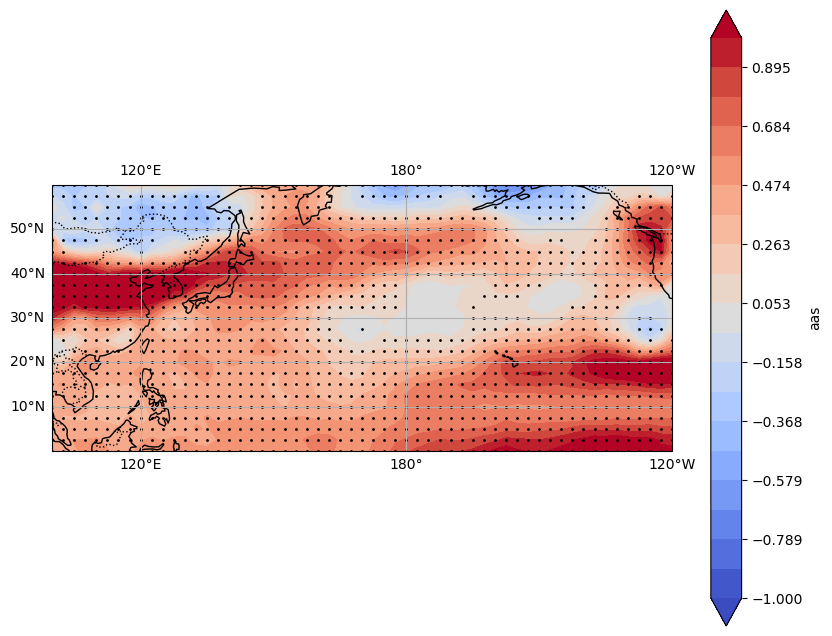

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100,240, 0,60], crs=ccrs.PlateCarree())

# 绘制网格线
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

vmin = -1
vmax = 1

# Create contour plot
contour = ax.contourf(lonaas, lataas,  as_diff, cmap='coolwarm', levels=np.linspace(vmin, vmax, 20), extend='both',transform=ccrs.PlateCarree())

# 在显著性通过95%的地方打黑点
significant_points_aas = np.where(significant_aas)
ax.scatter(lonaas[significant_points_aas[1]], lataas[significant_points_aas[0]], color='black', s=1, transform=ccrs.PlateCarree())

cbar = plt.colorbar(contour, ax=ax, orientation='vertical', label='aas')

plt.show()

In [25]:
sta_flattened = as_diff.values.flatten()
data_dict = {
    'as':sta_flattened    
}
df = pd.DataFrame(data_dict)
output_file_path = 'as.xlsx'
df.to_excel(output_file_path, index=False)
output_file_path

'as.xlsx'

In [28]:
data_dict = {
    'significant_points_lon': lonaas[significant_points_aas[1]],
    'significant_points_lat': lataas[significant_points_aas[0]]
}
df = pd.DataFrame(data_dict)
output_file_path = 'significant_points_as.xlsx'
df.to_excel(output_file_path, index=False)
output_file_path

'significant_points_as.xlsx'